# Инициализация проекта

In [201]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings

In [202]:
data = pd.read_csv('../data/forestfires.csv', sep=",", encoding="utf-8")

# Исследование исходных данных

Датасет содержит следующие поля:

- `X` пространственная координата по оси x на карте парка Монтесиньо: от 1 до 9
- `Y` пространственная координата по оси Y на карте парка Монтесиньо: от 2 до 9
- `month` (месяц) месяц года: от "янв" до "декабрь"
- `day` (день) день недели: от "пн" до "вс"
- `FFMC` индекс FFMC из системы FWI: от 18,7 до 96,20.
- `DMC` индекс DMC из системы FWI: от 1,1 до 291,3
- `DC` индекс DC из системы FWI: от 7,9 до 860,6
- `ISI` индекс ISI из системы FWI: от 0,0 до 56,10
- `temp` температура в градусах Цельсия: от 2,2 до 33,30
- `RH` относительная влажность в %: от 15,0 до 100
- `wind` (ветер) скорость ветра в км/ч: от 0,40 до 9,40
- `rain` (дождь) дождь снаружи в мм/м2: от 0,0 до 6,4
- `area` сгоревшая площадь леса (в га): от 0,00 до 1090,84

In [203]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    str    
 3   day     517 non-null    str    
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), str(2)
memory usage: 52.6 KB


In [204]:
data.head(20)

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0
5,8,6,aug,sun,92.3,85.3,488.0,14.7,22.2,29,5.4,0.0,0.0
6,8,6,aug,mon,92.3,88.9,495.6,8.5,24.1,27,3.1,0.0,0.0
7,8,6,aug,mon,91.5,145.4,608.2,10.7,8.0,86,2.2,0.0,0.0
8,8,6,sep,tue,91.0,129.5,692.6,7.0,13.1,63,5.4,0.0,0.0
9,7,5,sep,sat,92.5,88.0,698.6,7.1,22.8,40,4.0,0.0,0.0


**Получили следующую характеристику исходных данных:**

- Во всех столбцах отсутствуют пустые значения;
- Тип данных "month" и "day" нужно перевести в целочисленный.

In [205]:
months = {
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4,
    'may': 5, 'jun': 6, 'jul': 7, 'aug': 8,
    'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
}

data['month'] = data['month'].map(months).astype('int64')

In [206]:
days = {
    'mon': 1, 'tue': 2, 'wed': 3, 'thu': 4,
    'fri': 5, 'sat': 6, 'sun': 7
}

data['day'] = data['day'].map(days).astype('int64')

**Проверим данные на дубликаты**

In [207]:
data.duplicated().sum()

np.int64(4)

In [208]:
data = data.drop_duplicates()

In [209]:
data.describe()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000,513.000000
mean,4.678363,4.300195,7.485380,4.251462,90.637427,110.989279,549.155166,9.023587,18.887524,44.348928,4.010526,0.021832,12.891598
std,2.320059,1.230925,2.275095,2.075038,5.540920,64.191013,247.724594,4.575543,5.828128,16.358803,1.796613,0.297107,63.892586
min,1.000000,2.000000,1.000000,1.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,7.000000,2.000000,90.200000,68.600000,440.900000,6.400000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,8.000000,5.000000,91.600000,108.300000,664.500000,8.400000,19.300000,42.000000,4.000000,0.000000,0.540000
75%,7.000000,5.000000,9.000000,6.000000,92.900000,142.400000,713.900000,11.000000,22.800000,53.000000,4.900000,0.000000,6.570000
max,9.000000,9.000000,12.000000,7.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000


## Проведем визуальный анализ

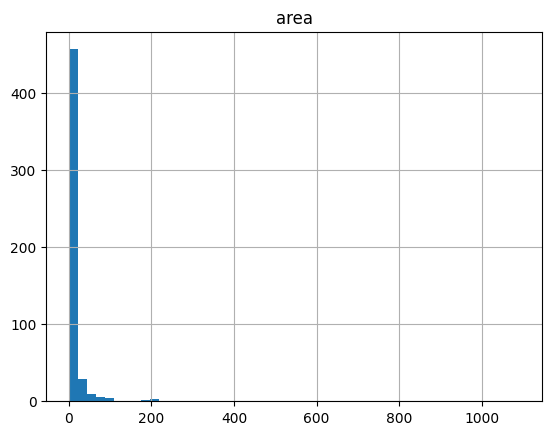

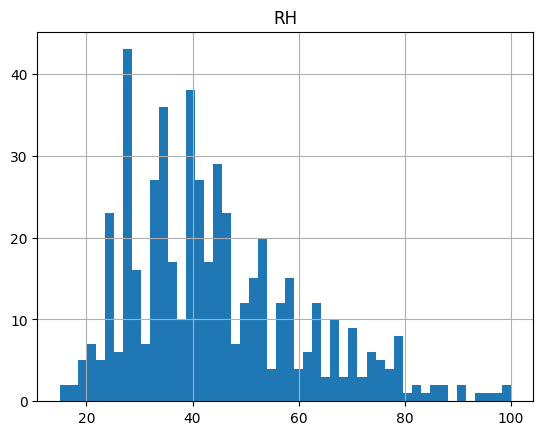

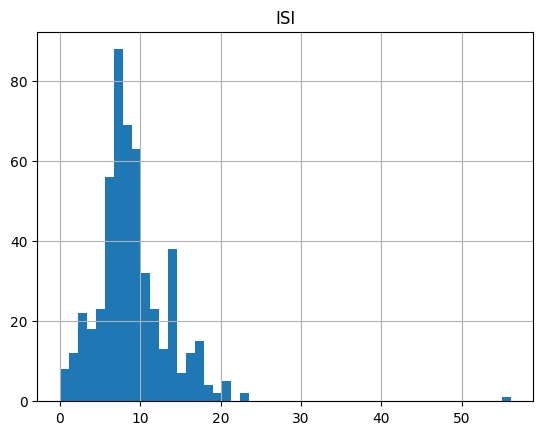

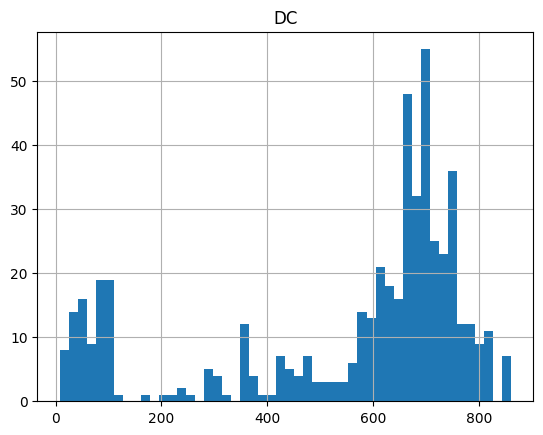

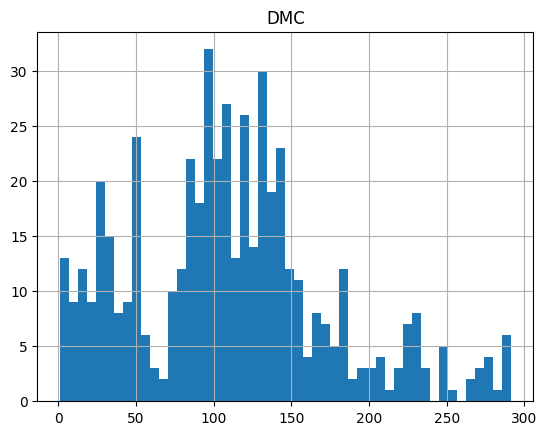

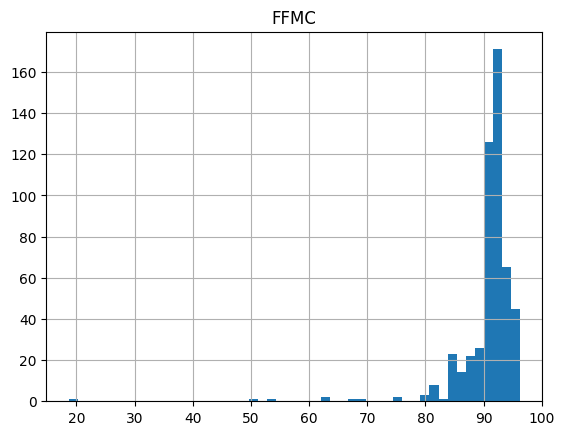

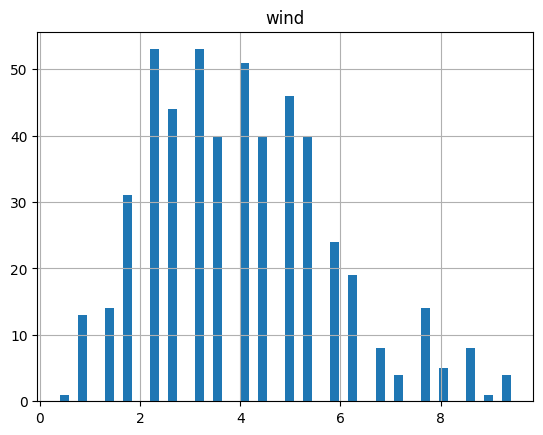

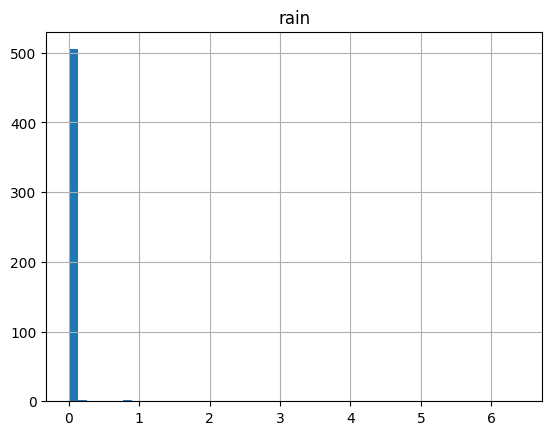

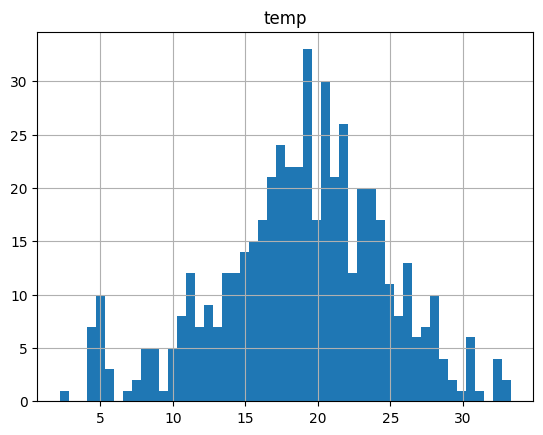

In [ ]:
columns = ['area','RH','ISI','DC','DMC', 'FFMC', 'wind', 'rain', 'temp']

for column in columns:
    data.hist(column, bins=50)

**Заключение:**
- выбросы затрудняют чтение данных об области пожара, дожде, FFMC, ISI;
- на гистограмме данные области пожара, дождя и ISI смещены вправо, а FFMC влево;
- тогда среднее значение обычно больше медианы.

Учитывая приведенные выше результаты, столбцы, содержащие выбросы - это 'area', 'rain', 'FFMC' и 'ISI'. Создадим DataFrame без этих выбросов. 

In [211]:
outlier = data[['area','rain','FFMC', 'ISI']]
outlier

,area,rain,FFMC,ISI
0,0.00,0.0,86.2,5.1
1,0.00,0.0,90.6,6.7
2,0.00,0.0,90.6,6.7
3,0.00,0.2,91.7,9.0
4,0.00,0.0,89.3,9.6
...,...,...,...,...
512,6.44,0.0,81.6,1.9
513,54.29,0.0,81.6,1.9
514,11.16,0.0,81.6,1.9
515,0.00,0.0,94.4,11.3


Определяем нижние пределы для выбросов

In [212]:
Q1 = outlier.quantile(0.25)
Q1

area     0.0
rain     0.0
FFMC    90.2
ISI      6.4
Name: 0.25, dtype: float64

Определяем верхние пределы для выбросов

In [213]:
Q3 = outlier.quantile(0.75)
Q3

area     6.57
rain     0.00
FFMC    92.90
ISI     11.00
Name: 0.75, dtype: float64

Получим отфильтрованные данные, из которых удалены выбросы

In [214]:
IQR = Q3-Q1
data_filtered = outlier[~((outlier < (Q1 - 1.5 * IQR)) |(outlier > (Q3 + 1.5 * IQR))).any(axis=1)]
data_filtered

,area,rain,FFMC,ISI
0,0.00,0.0,86.2,5.1
1,0.00,0.0,90.6,6.7
2,0.00,0.0,90.6,6.7
4,0.00,0.0,89.3,9.6
5,0.00,0.0,92.3,14.7
...,...,...,...,...
506,0.00,0.0,91.0,7.1
507,0.00,0.0,91.0,7.1
508,0.00,0.0,91.0,7.1
510,0.43,0.0,91.0,7.1


In [215]:
index_list = list(data_filtered.index.values)

data_filtered = data[data.index.isin(index_list)]
data_filtered.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,3,5,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,10,2,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,10,6,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
4,8,6,3,7,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0
5,8,6,8,7,92.3,85.3,488.0,14.7,22.2,29,5.4,0.0,0.0


Новая переменная сохранила отфильтрованные данные без выбросов. Далее отфильтрованные данные будут использоваться для создания гистограммы.

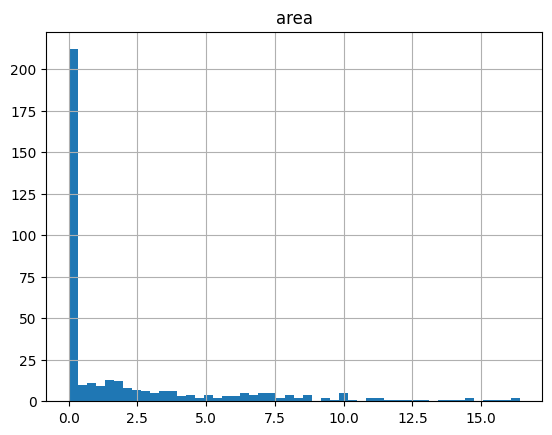

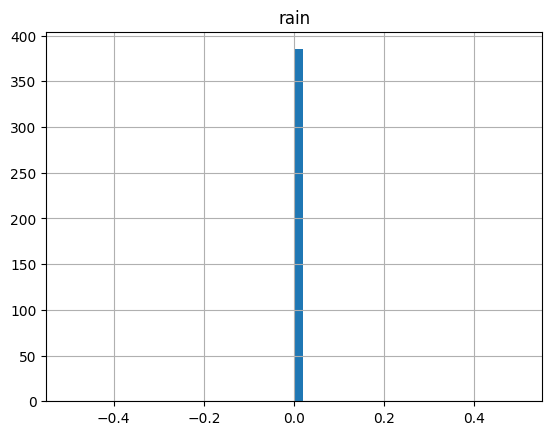

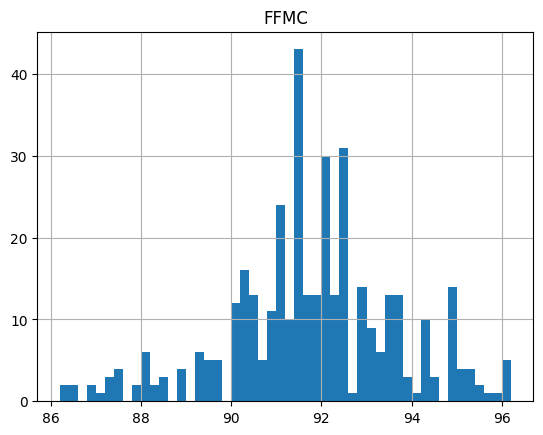

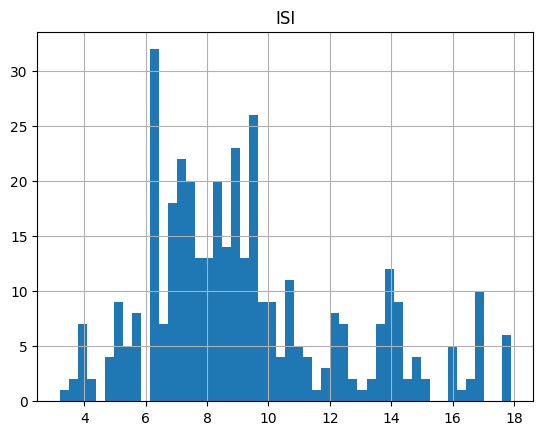

In [216]:
filtered_outlier = data_filtered[['area','rain','FFMC', 'ISI']]

for col in filtered_outlier:
    data_filtered.hist(col, bins=50)

Чтобы увидеть более детальную информацию по графикам 'area' и 'rain' стоит рассмотреть их без нулевых значений

In [217]:
rain_cleaned = data_filtered[data_filtered['rain'] != 0][['rain']]
len(rain_cleaned)

0

array([[<Axes: title={'center': 'area'}>]], dtype=object)

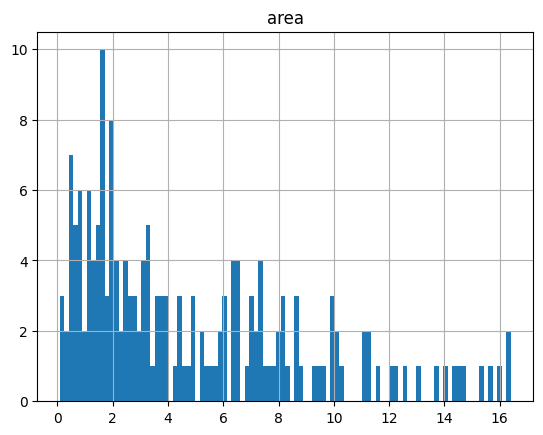

In [218]:
area_cleaned = data_filtered[data_filtered['area'] != 0][['area']]
area_cleaned.hist('area', bins=100)

**Выводы:**

- столбец 'rain' не несет смысла, так как все значения в нем равны 0 (можно удалить)
- значения в столбце 'area' имеют нормальное распределение, если брать случаи area > 0

In [219]:
data_filtered = data_filtered.drop('rain', axis = 1)
data_filtered.head(5)

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,area
0,7,5,3,5,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0
1,7,4,10,2,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0
2,7,4,10,6,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0
4,8,6,3,7,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0
5,8,6,8,7,92.3,85.3,488.0,14.7,22.2,29,5.4,0.0


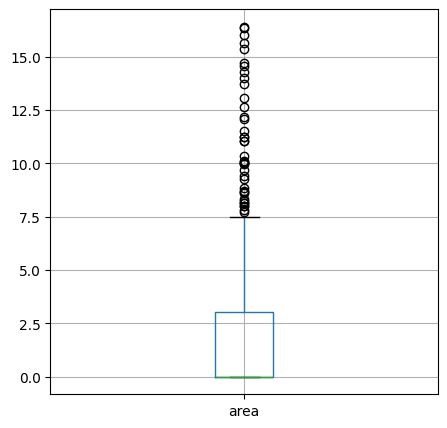

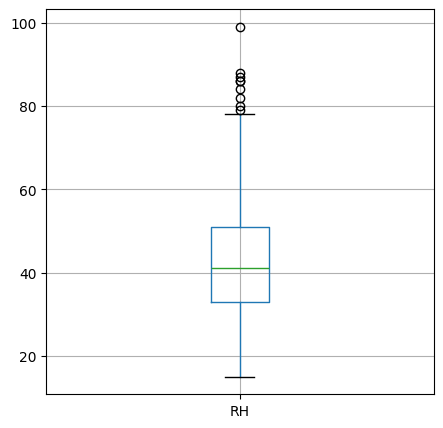

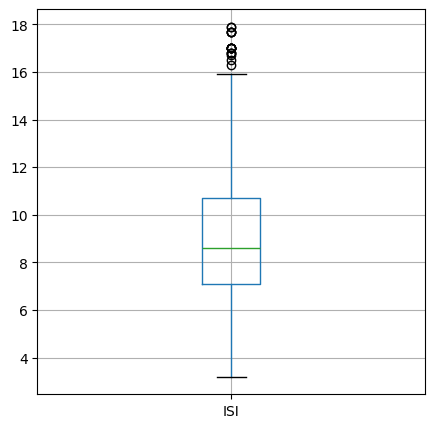

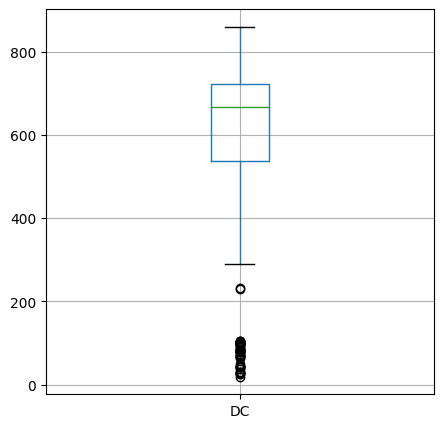

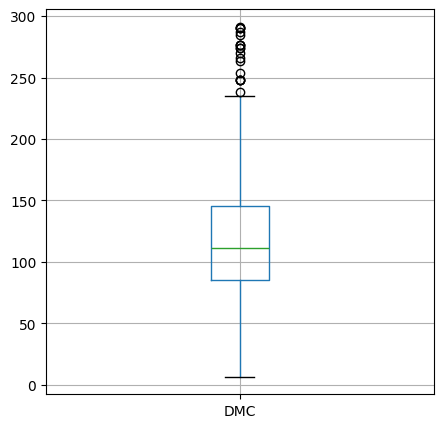

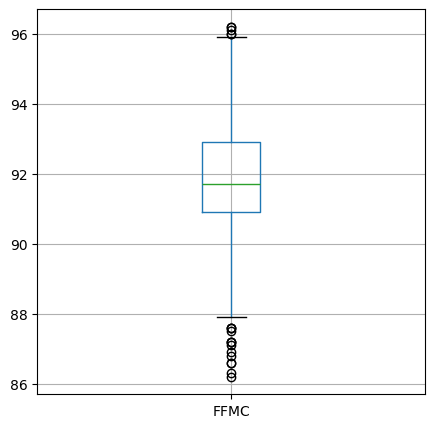

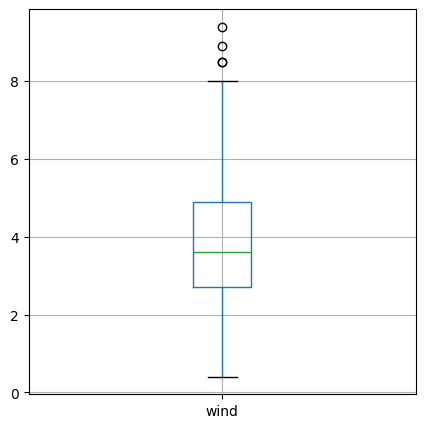

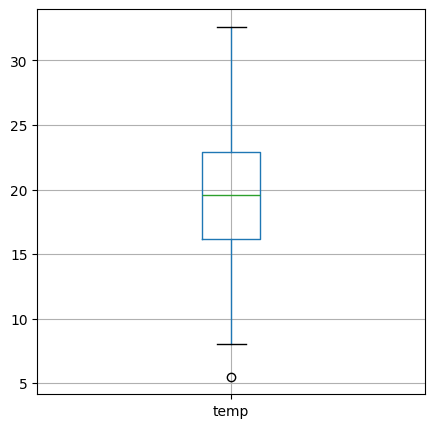

In [220]:
columns = ['area','RH','ISI','DC','DMC', 'FFMC', 'wind', 'temp']

for column in columns:
    plt.figure(figsize=(5, 5))
    data_filtered.boxplot(column)
    plt.show()

**Вывод:**

Данные значения корректно отражают реальный процесс и интерпретируются как значимые аномалии в данных

<Axes: >

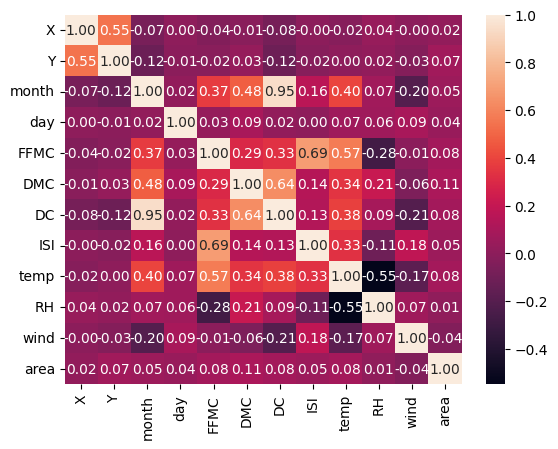

In [221]:
sns.heatmap(data_filtered.corr(), annot = True, fmt = '.2f')

**Вывод:**

По матрице корреляции видно, что между area и другими параметрами нет линейной зависимости

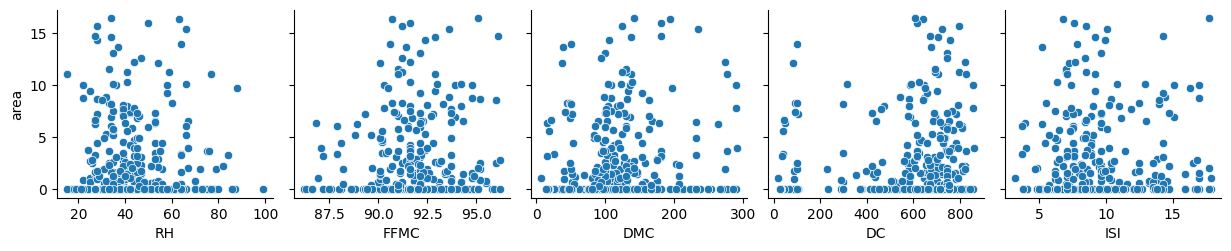

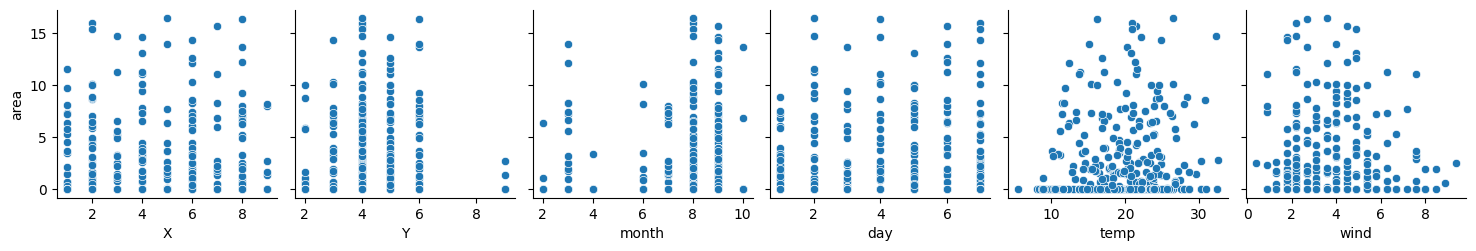

In [222]:
sns.pairplot(data_filtered, y_vars=["area"], x_vars=["RH", "FFMC", "DMC", "DC", "ISI"])
sns.pairplot(data_filtered, y_vars=["area"], x_vars=["X", "Y", "month", "day", "temp", "wind"])

<b>Выводы из графиков:</b>

- Графики зависимости "area" от параметров "X", "Y", "Month" и "Day" не показывают однозначную взаимосвязь
- Остальные параметры показывают нечто похожее на нормальное распределение со смещением